In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
from statsmodels.regression.mixed_linear_model import MixedLM
import pingouin as pg

# Configuración de plots
sns.set(font_scale=1.3, style="ticks")
plt.rcParams["figure.dpi"] = 100

print("librerias OK")


librerias OK


In [2]:
def RT_filter(x, sd):
    rt_mean = x["RT"].mean()
    up_lim  = rt_mean + sd * x["RT"].std()
    return x[x["RT"] < up_lim]


def log_reg_fit(x, f):
    """Ajusta GLM binomial y extrae intercept, weight (pendiente) y PSE."""
    try:
        reg = smf.glm(formula=f, data=x, family=sm.families.Binomial()).fit(disp=0)
        intercept = reg.params["Intercept"]
        weight    = reg.params["rDV"]
        PSE       = -intercept / weight
        return pd.DataFrame([[intercept, weight, PSE]],
                            columns=["intercept", "weight", "PSE"])
    except Exception:
        return pd.DataFrame([[np.nan, np.nan, np.nan]],
                            columns=["intercept", "weight", "PSE"])


def switch_strategy(data):
    """Calcula stubbornness (terquedad) = p(no cambiar tras error)."""
    dfwrong = data[data["corr-1"] == 0]["switch"]
    phit    = dfwrong.mean() if len(dfwrong) > 0 else 0.0001
    if phit == 0: phit = 0.0001

    dfright = data[data["corr-1"] == 1]["switch"]
    pfa     = dfright.mean() if len(dfright) > 0 else 0.0001
    if pfa == 0: pfa = 0.0001

    stuborness = 1 - phit
    return pd.DataFrame([[phit, pfa, stuborness]],
                        columns=["phit", "pfa", "stuborness"])


In [3]:
data_path = "/Users/martu/Documents/TFG_MARTINA/dataset/CJ_EEG.csv"

all_df = pd.read_csv(data_path)
print(f"Dataset cargado: {all_df.shape[0]} filas, {all_df.shape[1]} columnas")
all_df.head(3)


Dataset cargado: 6600 filas, 36 columnas


,exp_ID,npar,subj,nblock,ntrial,nrep,cond-1,trial_type,rDV,deci-3,...,d6,o1,o2,o3,o4,o5,o6,metad,metad_3%,metad_97%
0,CJ_EEG,1,s01,0,0,0,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
1,CJ_EEG,1,s01,0,0,1,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
2,CJ_EEG,1,s01,0,0,2,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51


In [4]:
df = all_df.copy()

# Recodificación
df["cond"]    = df["cond"].replace([-1], 0)
df["correct"] = df["correct"].replace([-1], 0)

# switch: 1 si cambió de decisión, 0 si la mantuvo
df["switch"] = 1
df.loc[df["deci"] == df["deci-1"], "switch"] = 0

# conf_lvl: confianza binarizada
median_confi = df["confi"].median()
df["conf_lvl"] = "L"
df.loc[df["confi"] >= median_confi, "conf_lvl"] = "H"

# confi-1: confianza del trial anterior (dentro del mismo trial)
df = df.sort_values(["subj", "nblock", "ntrial", "nrep"]).reset_index(drop=True)
df["confi-1"] = df.groupby(["subj", "nblock", "ntrial"])["confi"].shift(1)

# correct-1: alias de corr-1 para compatibilidad
df["correct-1"] = df["corr-1"]

print(f"cond      → {sorted(df['cond'].unique())}")
print(f"correct   → {sorted(df['correct'].unique())}")
print(f"switch    → {sorted(df['switch'].unique())}")
print(f"conf_lvl  → {sorted(df['conf_lvl'].unique())}")
print(f"nrep      → {sorted(df['nrep'].unique())}")
print(f"NaN confi-1  : {df['confi-1'].isna().sum()}")
print(f"NaN correct-1: {df['correct-1'].isna().sum()}")
print(f"Total filas  : {len(df)}")


cond      → [np.int64(0), np.int64(1)]
correct   → [np.int64(0), np.int64(1)]
switch    → [np.int64(0), np.int64(1)]
conf_lvl  → ['H', 'L']
nrep      → [np.int64(0), np.int64(1), np.int64(2)]
NaN confi-1  : 2200
NaN correct-1: 0
Total filas  : 6600


In [5]:
nulos = df.isnull().sum()
print("Columnas con valores nulos:")
print(nulos[nulos > 0])


Columnas con valores nulos:
metad         264
metad_3%      264
metad_97%     264
confi-1      2200
dtype: int64


In [6]:
df_rt = df.groupby(["npar"], group_keys=False).apply(RT_filter, sd=4)
df_rt = df_rt.reset_index(drop=True)

filas_antes   = len(df)
filas_despues = len(df_rt)
print(f"Trials antes del filtro : {filas_antes}")
print(f"Trials después del filtro: {filas_despues}")
print(f"Trials eliminados        : {filas_antes - filas_despues} ({(filas_antes - filas_despues)/filas_antes*100:.1f}%)")
print(f"NaN confi-1 en df_rt  : {df_rt['confi-1'].isna().sum()}")
print(f"NaN correct-1 en df_rt: {df_rt['correct-1'].isna().sum()}")


Trials antes del filtro : 6600
Trials después del filtro: 6537
Trials eliminados        : 63 (1.0%)
NaN confi-1 en df_rt  : 2167
NaN correct-1 en df_rt: 0


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_71586/3583210374.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_rt = df.groupby(["npar"], group_keys=False).apply(RT_filter, sd=4)


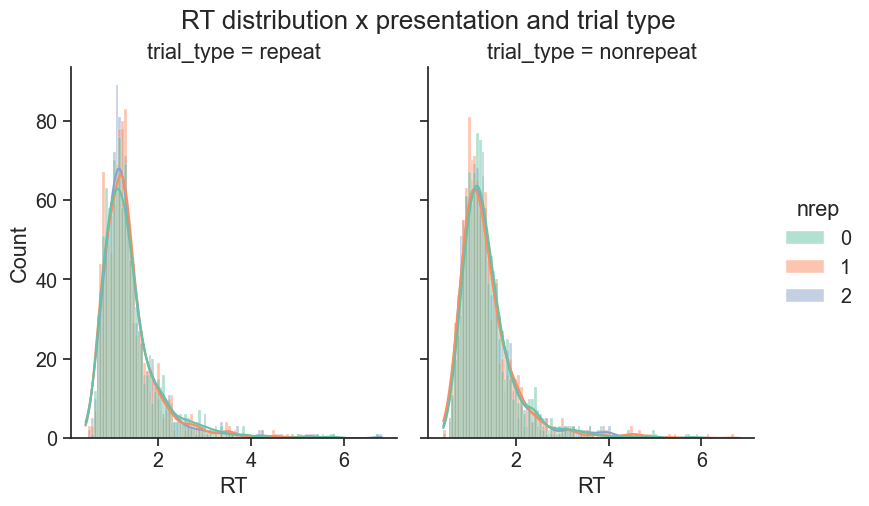

In [7]:
sns.displot(
    data=df_rt, x="RT", hue="nrep", col="trial_type",
    height=5, aspect=0.8, kind="hist", kde=True, palette="Set2"
)
plt.suptitle("RT distribution x presentation and trial type", y=1.02)
plt.show()


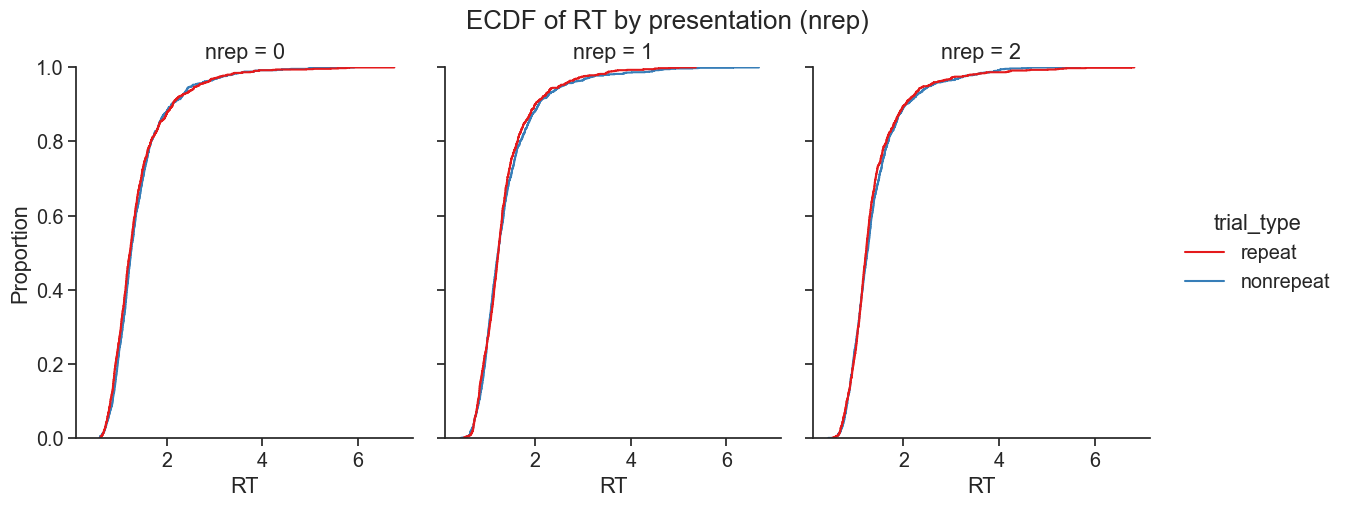

In [8]:
sns.displot(
    data=df_rt, x="RT", hue="trial_type", col="nrep",
    height=5, aspect=0.8, kind="ecdf", palette="Set1"
)
plt.suptitle("ECDF of RT by presentation (nrep)", y=1.02)
plt.show()


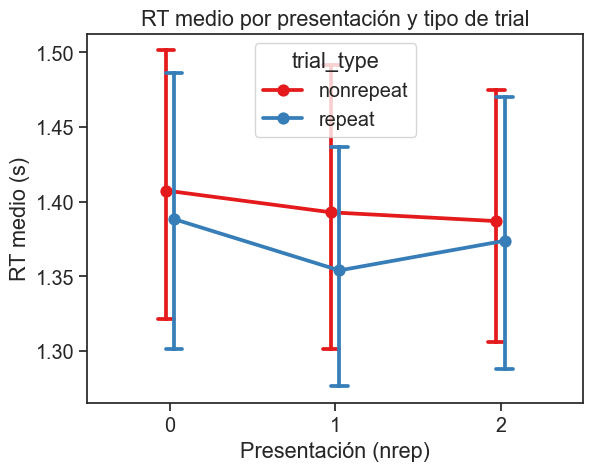

ANOVA de medidas repetidas — RT:
              Source        SS  ddof1  ddof2        MS         F     p_unc  \
0               nrep  0.015881      2     48  0.007941  0.760550  0.472958   
1         trial_type  0.021077      1     24  0.021077  4.968846  0.035429   
2  nrep * trial_type  0.004530      2     48  0.002265  0.304661  0.738789   

   p_GG_corr       ng2       eps  
0   0.465558  0.001953  0.938157  
1   0.035429  0.002591  1.000000  
2   0.728074  0.000558  0.951419  


In [9]:
avg_rt = df_rt.groupby(["subj", "nrep", "trial_type"], as_index=False)[["RT"]].mean()

sns.pointplot(data=avg_rt, x="nrep", y="RT", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1")
plt.xlabel("Presentación (nrep)")
plt.ylabel("RT medio (s)")
plt.title("RT medio por presentación y tipo de trial")
plt.show()

print("ANOVA de medidas repetidas — RT:")
print(pg.rm_anova(dv="RT", within=["nrep", "trial_type"],
                  subject="subj", data=avg_rt, detailed=True, correction=True))


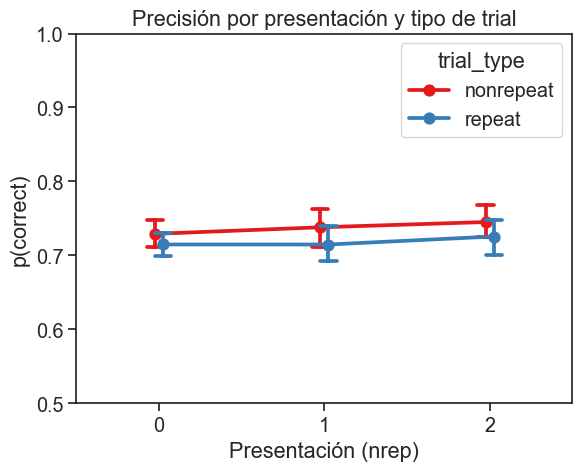

ANOVA de medidas repetidas — Precisión:
              Source        SS  ddof1  ddof2        MS         F     p_unc  \
0               nrep  0.004650      2     48  0.002325  1.006835  0.372958   
1         trial_type  0.013649      1     24  0.013649  2.359494  0.137602   
2  nrep * trial_type  0.000498      2     48  0.000249  0.159866  0.852710   

   p_GG_corr       ng2       eps  
0   0.368249  0.009858  0.924794  
1   0.137602  0.028393  1.000000  
2   0.849086  0.001065  0.982139  


In [10]:
avg_correct = df_rt.groupby(["subj", "nrep", "trial_type"], as_index=False)[["correct"]].mean()

sns.pointplot(data=avg_correct, x="nrep", y="correct", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1")
plt.xlabel("Presentación (nrep)")
plt.ylabel("p(correct)")
plt.title("Precisión por presentación y tipo de trial")
plt.ylim(0.5, 1.0)
plt.show()

print("ANOVA de medidas repetidas — Precisión:")
print(pg.rm_anova(dv="correct", within=["nrep", "trial_type"],
                  subject="subj", data=avg_correct, detailed=True, correction=True))


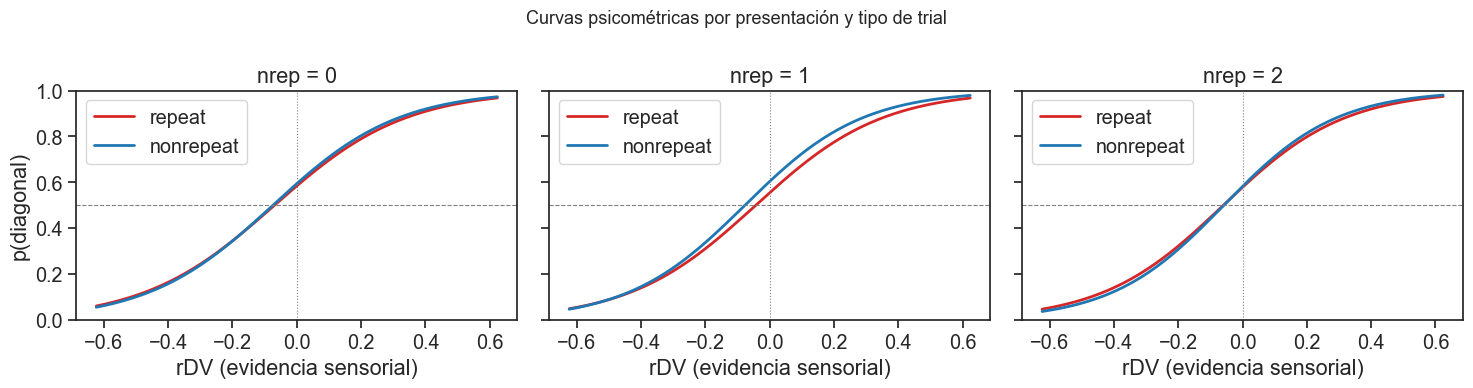

In [11]:
import scipy.special as sps

rdv_range = np.linspace(df_rt["rDV"].min(), df_rt["rDV"].max(), 200)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, nrep_val in zip(axes, [0, 1, 2]):
    subset = df_rt[df_rt["nrep"] == nrep_val]
    for tt, color in zip(["repeat", "nonrepeat"], ["tab:red", "tab:blue"]):
        data_tt = subset[subset["trial_type"] == tt]
        reg = smf.glm("deci ~ rDV", data=data_tt, family=sm.families.Binomial()).fit(disp=0)
        y_pred = sps.expit(reg.params["Intercept"] + reg.params["rDV"] * rdv_range)
        ax.plot(rdv_range, y_pred, color=color, label=tt, linewidth=2)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(0.0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(f"nrep = {nrep_val}")
    ax.set_xlabel("rDV (evidencia sensorial)")
    ax.set_ylabel("p(diagonal)" if nrep_val == 0 else "")
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle("Curvas psicométricas por presentación y tipo de trial", fontsize=13)
plt.tight_layout()
plt.show()


In [12]:
formula = "deci ~ rDV"
log_reg_nrep = df_rt.groupby(["subj", "nrep", "trial_type"]).apply(
    log_reg_fit, formula, include_groups=False
)
log_reg_nrep.reset_index(inplace=True)
log_reg_nrep.drop(columns="level_3", errors="ignore", inplace=True)
print(log_reg_nrep.head(6))


  subj  nrep trial_type  intercept    weight       PSE
0  S03     0  nonrepeat   1.180302  5.832419 -0.202369
1  S03     0     repeat   1.088192  7.483183 -0.145418
2  S03     1  nonrepeat   1.185358  9.552448 -0.124089
3  S03     1     repeat   0.572640  7.104382 -0.080604
4  S03     2  nonrepeat   0.937739  4.549234 -0.206131
5  S03     2     repeat   1.423058  8.940153 -0.159176


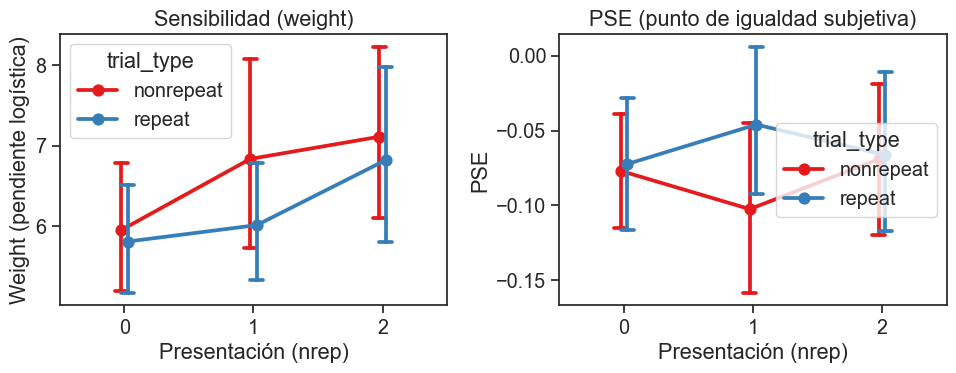

ANOVA — Weight:
              Source         SS  ddof1  ddof2         MS         F     p_unc  \
0               nrep  29.375285      2     48  14.687643  4.839441  0.012173   
1         trial_type   6.531766      1     24   6.531766  0.632592  0.434202   
2  nrep * trial_type   3.189370      2     48   1.594685  0.712887  0.495343   

   p_GG_corr       ng2       eps  
0   0.012842  0.032725  0.976198  
1   0.434202  0.007467  1.000000  
2   0.465209  0.003660  0.789810  
ANOVA — PSE:
              Source        SS  ddof1  ddof2        MS         F     p_unc  \
0               nrep  0.001529      2     48  0.000764  0.171108  0.843243   
1         trial_type  0.017002      1     24  0.017002  2.098514  0.160383   
2  nrep * trial_type  0.023301      2     48  0.011650  3.926774  0.026337   

   p_GG_corr       ng2       eps  
0   0.827720  0.000625  0.927944  
1   0.160383  0.006902  1.000000  
2   0.036438  0.009435  0.799965  


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.pointplot(data=log_reg_nrep, x="nrep", y="weight", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].set_title("Sensibilidad (weight)")
axes[0].set_xlabel("Presentación (nrep)")
axes[0].set_ylabel("Weight (pendiente logística)")

sns.pointplot(data=log_reg_nrep, x="nrep", y="PSE", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[1])
axes[1].set_title("PSE (punto de igualdad subjetiva)")
axes[1].set_xlabel("Presentación (nrep)")
axes[1].set_ylabel("PSE")

plt.tight_layout()
plt.show()

print("ANOVA — Weight:")
print(pg.rm_anova(dv="weight", within=["nrep", "trial_type"],
                  subject="subj", data=log_reg_nrep, detailed=True, correction=True))
print("ANOVA — PSE:")
print(pg.rm_anova(dv="PSE", within=["nrep", "trial_type"],
                  subject="subj", data=log_reg_nrep, detailed=True, correction=True))


In [15]:
formula = "deci ~ rDV"
log_reg_preDeci = df_rt.groupby(["subj", "nrep", "deci-1", "trial_type"]).apply(
    log_reg_fit, formula, include_groups=False
)
log_reg_preDeci.reset_index(inplace=True)
log_reg_preDeci.drop(columns="level_4", errors="ignore", inplace=True)

log_reg_preDeci["prev_decision"] = log_reg_preDeci["deci-1"].map(
    {0: "Cardinal", 1: "Diagonal"}
)

print(log_reg_preDeci.head(8))


/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be

  subj  nrep  deci-1 trial_type  intercept     weight       PSE prev_decision
0  S03     0       0  nonrepeat   0.741612  15.779453 -0.046999      Cardinal
1  S03     0       0     repeat   1.777869  15.216221 -0.116840      Cardinal
2  S03     0       1  nonrepeat   1.368496   3.649800 -0.374951      Diagonal
3  S03     0       1     repeat   0.898460   6.002542 -0.149680      Diagonal
4  S03     1       0  nonrepeat  -1.201728   3.036159  0.395805      Cardinal
5  S03     1       0     repeat  -0.612319   5.594071  0.109459      Cardinal
6  S03     1       1  nonrepeat   3.959669  17.144523 -0.230958      Diagonal
7  S03     1       1     repeat   1.138756   4.975161 -0.228888      Diagonal


Filas originales : 300
Filas tras filtro: 273


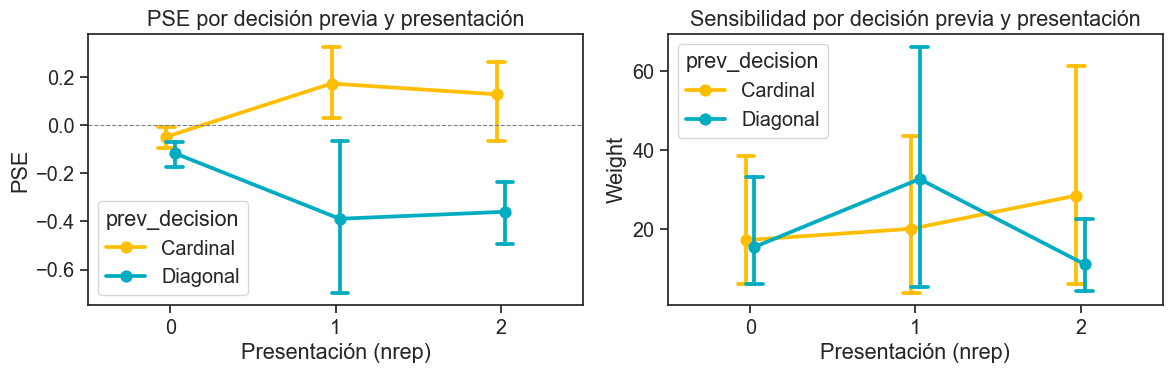

In [16]:
pse_limit = 5
log_reg_preDeci_clean = log_reg_preDeci[
    np.abs(log_reg_preDeci["PSE"]) < pse_limit
].copy()
print(f"Filas originales : {len(log_reg_preDeci)}")
print(f"Filas tras filtro: {len(log_reg_preDeci_clean)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.pointplot(data=log_reg_preDeci_clean, x="nrep", y="PSE",
              hue="prev_decision", dodge=True, capsize=0.1,
              palette=["#ffbf00", "#00acc1"], ax=axes[0])
axes[0].set_title("PSE por decisión previa y presentación")
axes[0].set_xlabel("Presentación (nrep)")
axes[0].set_ylabel("PSE")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)

sns.pointplot(data=log_reg_preDeci, x="nrep", y="weight",
              hue="prev_decision", dodge=True, capsize=0.1,
              palette=["#ffbf00", "#00acc1"], ax=axes[1])
axes[1].set_title("Sensibilidad por decisión previa y presentación")
axes[1].set_xlabel("Presentación (nrep)")
axes[1].set_ylabel("Weight")

plt.tight_layout()
plt.show()


In [17]:
dat = log_reg_preDeci[log_reg_preDeci["nrep"] > 0]

print("ANOVA — PSE condicionado a decisión previa:")
print(pg.rm_anova(dv="PSE", within=["nrep", "deci-1"],
                  subject="subj", data=dat, detailed=True, correction=True))
print("ANOVA — Weight condicionado a decisión previa:")
print(pg.rm_anova(dv="weight", within=["nrep", "deci-1"],
                  subject="subj", data=dat, detailed=True, correction=True))


ANOVA — PSE condicionado a decisión previa:
          Source   SS  ddof1  ddof2   MS   F  p_unc  p_GG_corr  ng2  eps
0           nrep  inf      1     24  inf NaN    NaN        NaN  NaN  1.0
1         deci-1  inf      1     24  inf NaN    NaN        NaN  NaN  1.0
2  nrep * deci-1  NaN      1     24  NaN NaN    NaN        NaN  NaN  1.0
ANOVA — Weight condicionado a decisión previa:
          Source           SS  ddof1  ddof2           MS         F     p_unc  \
0           nrep  1082.696194      1     24  1082.696194  0.264030  0.612064   
1         deci-1   144.389315      1     24   144.389315  0.033755  0.855772   
2  nrep * deci-1  5621.151440      1     24  5621.151440  1.485239  0.234801   

   p_GG_corr       ng2  eps  
0   0.612064  0.003027  1.0  
1   0.855772  0.000405  1.0  
2   0.234801  0.015517  1.0  


/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/pingouin/parametric.py:722: RuntimeWarning: invalid value encountered in scalar subtract
  ss_ab = ss_ab_er - ss_a - ss_b
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/pingouin/parametric.py:724: RuntimeWarning: invalid value encountered in scalar subtract
  ss_as = ss_as_er - ss_s - ss_a
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/pingouin/parametric.py:726: RuntimeWarning: invalid value encountered in scalar subtract
  ss_bs = ss_bs_er - ss_s - ss_b
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/pingouin/parametric.py:727: RuntimeWarning: invalid value encountered in scalar subtract
  ss_abs = ss_tot - ss_a - ss_b - ss_s - ss_ab - ss_as - ss_bs
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/numpy/lib/_function_base_im

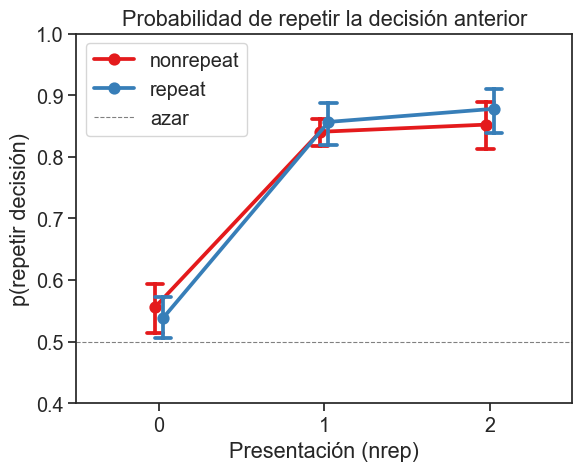

Media de p(repetir) por nrep:
nrep
0    0.547
1    0.849
2    0.865
Name: p_repeat, dtype: float64
Test t contra 0.5 (azar) por nrep:
nrep=0: t=3.544, p=0.0009 → SIGNIFICATIVO ✓
nrep=1: t=32.404, p=0.0000 → SIGNIFICATIVO ✓
nrep=2: t=25.912, p=0.0000 → SIGNIFICATIVO ✓


In [18]:
avg_switch = df_rt.groupby(
    ["subj", "nrep", "trial_type"], as_index=False
)[["switch"]].mean()
avg_switch["p_repeat"] = 1 - avg_switch["switch"]

sns.pointplot(data=avg_switch, x="nrep", y="p_repeat", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="azar")
plt.xlabel("Presentación (nrep)")
plt.ylabel("p(repetir decisión)")
plt.title("Probabilidad de repetir la decisión anterior")
plt.ylim(0.4, 1.0)
plt.legend()
plt.show()

print("Media de p(repetir) por nrep:")
print(avg_switch.groupby("nrep")["p_repeat"].mean().round(3))

print("Test t contra 0.5 (azar) por nrep:")
for nrep_val in [0, 1, 2]:
    dat = avg_switch[avg_switch["nrep"] == nrep_val]["p_repeat"]
    t, p = stats.ttest_1samp(dat, 0.5)
    print(f"nrep={nrep_val}: t={t:.3f}, p={p:.4f} → "          f"{'SIGNIFICATIVO ✓' if p < 0.05 else 'no significativo'}")


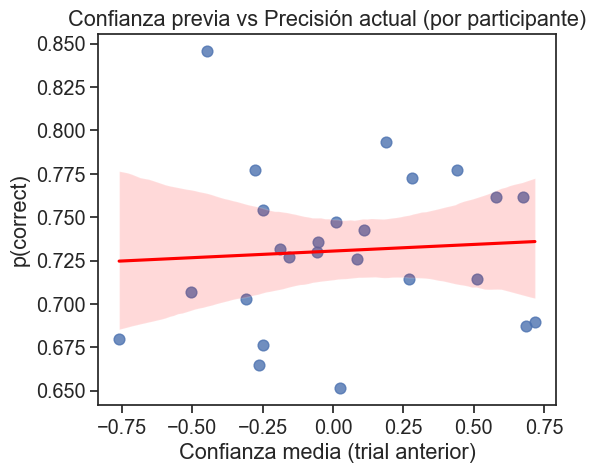

Correlación confianza previa ~ precisión actual:
          n      r           CI95  p_val   BF10  power
pearson  25  0.069  [-0.34, 0.45]  0.745  0.261  0.062


In [19]:
df_meta_tmp = df_rt[df_rt["nrep"] > 0].copy()
avg_subj = df_meta_tmp.groupby("subj", as_index=False)[["confi-1", "correct"]].mean()

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(data=avg_subj, x="confi-1", y="correct",
            scatter_kws={"s": 60}, line_kws={"color": "red"}, ax=ax)
ax.set_title("Confianza previa vs Precisión actual (por participante)")
ax.set_xlabel("Confianza media (trial anterior)")
ax.set_ylabel("p(correct)")
plt.tight_layout()
plt.show()

corr = pg.corr(avg_subj["confi-1"], avg_subj["correct"], method="pearson")
print("Correlación confianza previa ~ precisión actual:")
print(corr.round(3))


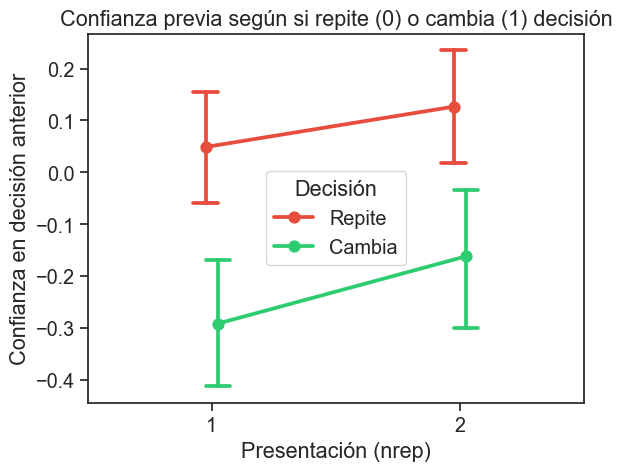

In [20]:
avg_confi_switch = df_rt.groupby(
    ["subj", "nrep", "switch", "trial_type"], as_index=False
)[["confi", "confi-1"]].mean()

sns.pointplot(
    data=avg_confi_switch[avg_confi_switch["nrep"] > 0],
    x="nrep", y="confi-1", hue="switch",
    dodge=True, capsize=0.1, palette={0: "#e74c3c", 1: "#2ecc71"}
)
plt.title("Confianza previa según si repite (0) o cambia (1) decisión")
plt.xlabel("Presentación (nrep)")
plt.ylabel("Confianza en decisión anterior")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Repite", "Cambia"], title="Decisión")
plt.show()


Participantes con metad disponible: 24
Media metad: 0.628
Std  metad : 0.317
Rango: [0.086, 1.226]


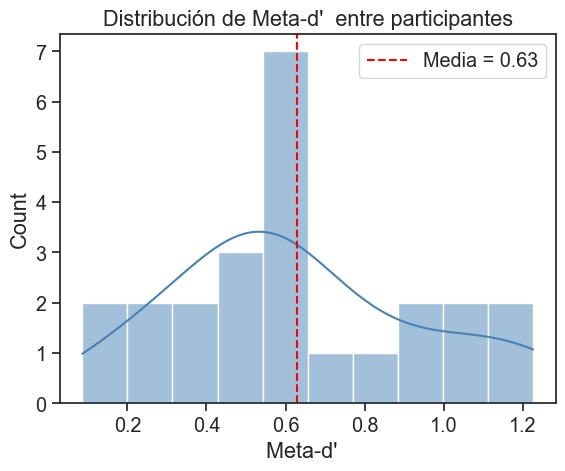

In [21]:
metad_subj = df_rt.groupby("subj", as_index=False)["metad"].first()
metad_subj = metad_subj.dropna()

print(f"Participantes con metad disponible: {len(metad_subj)}")
print(f"Media metad: {metad_subj['metad'].mean():.3f}")
print(f"Std  metad : {metad_subj['metad'].std():.3f}")
print(f"Rango: [{metad_subj['metad'].min():.3f}, {metad_subj['metad'].max():.3f}]")

sns.histplot(data=metad_subj, x="metad", kde=True, bins=10, color="steelblue")
plt.axvline(metad_subj["metad"].mean(), color="red", linestyle="--",
            label=f"Media = {metad_subj['metad'].mean():.2f}")
plt.title("Distribución de Meta-d'  entre participantes")
plt.xlabel("Meta-d'  ")
plt.legend()
plt.show()


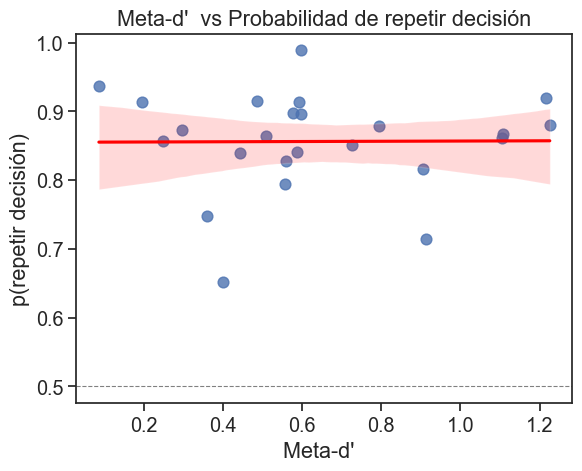

Correlación Meta-d'  ~ p(repetir):
          n      r          CI95  p_val   BF10  power
pearson  24  0.007  [-0.4, 0.41]  0.973  0.253   0.05


In [22]:
avg_repeat_subj = df_rt[df_rt["nrep"] > 0].groupby(
    "subj", as_index=False
)["switch"].mean()
avg_repeat_subj["p_repeat"] = 1 - avg_repeat_subj["switch"]
avg_repeat_subj = avg_repeat_subj.merge(metad_subj, on="subj")

sns.regplot(data=avg_repeat_subj, x="metad", y="p_repeat",
            scatter_kws={"s": 60}, line_kws={"color": "red"})
plt.title("Meta-d'  vs Probabilidad de repetir decisión")
plt.xlabel("Meta-d'  ")
plt.ylabel("p(repetir decisión)")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
plt.show()

corr_metad = pg.corr(avg_repeat_subj["metad"], avg_repeat_subj["p_repeat"], method="pearson")
print("Correlación Meta-d'  ~ p(repetir):")
print(corr_metad.round(3))


In [26]:
def log_stimmultreg_fit(x, f):
    """
    Regresión logística con los 6 estímulos + deci-1 como control.
    Controlar por deci-1 aísla el efecto sensorial puro de cada estímulo.
    """
    try:
        reg = smf.glm(formula=f, data=x,
                      family=sm.families.Binomial()).fit(disp=0)
        params = reg.params
        # La clave exacta que usa statsmodels para Q("deci-1")
        key_deci = 'Q("deci-1")'
        out = pd.DataFrame([[
            params.get('Intercept', np.nan),
            params.get(key_deci,    np.nan),
            params.get('d1',        np.nan),
            params.get('d2',        np.nan),
            params.get('d3',        np.nan),
            params.get('d4',        np.nan),
            params.get('d5',        np.nan),
            params.get('d6',        np.nan),
        ]], columns=['intercept', 'prev_deci',
                     'G1ori', 'G2ori', 'G3ori',
                     'G4ori', 'G5ori', 'G6ori'])
        return out
    except Exception:
        return pd.DataFrame([[np.nan]*8],
                            columns=['intercept', 'prev_deci',
                                     'G1ori', 'G2ori', 'G3ori',
                                     'G4ori', 'G5ori', 'G6ori'])

# Usamos comillas simples fuera y dobles dentro para Q()
formula_multi = 'deci ~ Q("deci-1") + d1 + d2 + d3 + d4 + d5 + d6'

df_mr_betas = df_rt[df_rt['nrep'] > 0].groupby(['subj', 'nrep']).apply(
    log_stimmultreg_fit, formula_multi, include_groups=False
)
df_mr_betas.reset_index(inplace=True)
df_mr_betas.drop(columns='level_2', errors='ignore', inplace=True)

print('Parámetros estimados (con deci-1 como control):')
print(df_mr_betas.head(6))
print(f'\nMedia del coeficiente deci-1: {df_mr_betas["prev_deci"].mean():.3f}')

/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be

Parámetros estimados (con deci-1 como control):
  subj  nrep  intercept  prev_deci     G1ori     G2ori     G3ori     G4ori  \
0  S03     1  -0.738072   2.384295  1.826190  0.885497  1.704319  0.642490   
1  S03     2   0.298415   1.281847  0.103004  0.271016  0.671488  1.566413   
2  s01     1  -6.145762  13.234472  4.584388  1.147548 -0.040511  0.260274   
3  s01     2  -1.808979   4.937182  3.421835  0.627369  0.907062  1.710324   
4  s04     1  -3.029982   6.096299  2.720048  2.557281  1.485334  2.417133   
5  s04     2  -1.408128   4.986310  1.942714  0.733209  2.110528  1.713245   

      G5ori     G6ori  
0  0.607304  1.436716  
1  0.802908  1.319533  
2  7.240296  0.499851  
3  1.901292  0.932104  
4  1.354409  1.245702  
5  0.597878 -0.403805  

Media del coeficiente deci-1: 7.003


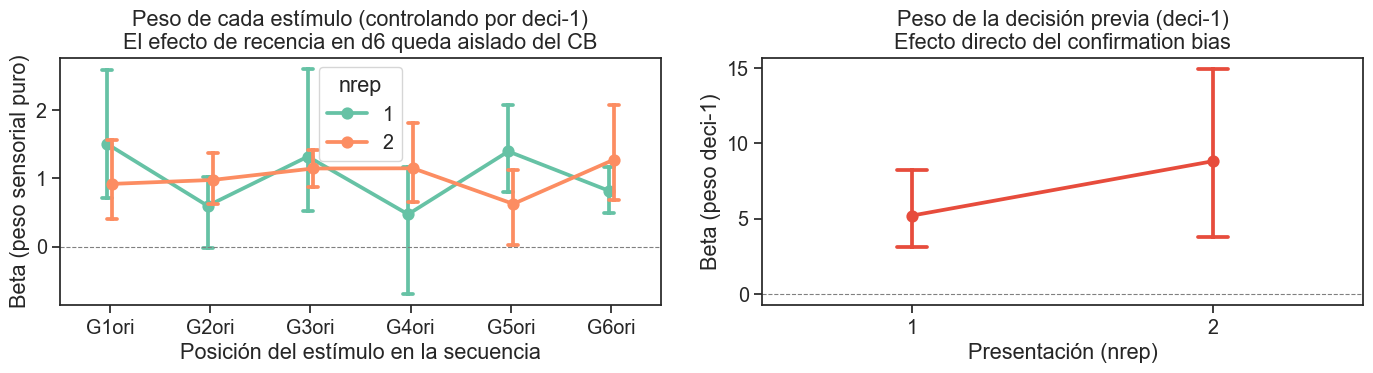

Test t del peso de deci-1 contra 0:
  nrep=1: t=3.592, p=0.0015 → SIGNIFICATIVO ✓
  nrep=2: t=3.025, p=0.0058 → SIGNIFICATIVO ✓


In [41]:
df_betas = pd.melt(
    df_mr_betas,
    id_vars=['subj', 'nrep'],
    value_vars=['G1ori', 'G2ori', 'G3ori', 'G4ori', 'G5ori', 'G6ori']
)
df_betas.rename(columns={'variable': 'parameter', 'value': 'value'}, inplace=True)
df_betas = df_betas.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.pointplot(data=df_betas, x='parameter', y='value', hue='nrep',
              dodge=True, capsize=0.1, palette='Set2', ax=axes[0])
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Peso de cada estímulo (controlando por deci-1)\n'
                  'El efecto de recencia en d6 queda aislado del CB')
axes[0].set_xlabel('Posición del estímulo en la secuencia')
axes[0].set_ylabel('Beta (peso sensorial puro)')

sns.pointplot(data=df_mr_betas, x='nrep', y='prev_deci',
              capsize=0.1, color='#e74c3c', ax=axes[1])
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Peso de la decisión previa (deci-1)\n'
                  'Efecto directo del confirmation bias')
axes[1].set_xlabel('Presentación (nrep)')
axes[1].set_ylabel('Beta (peso deci-1)')

plt.tight_layout()
plt.show()

print('Test t del peso de deci-1 contra 0:')
for nrep_val in [1, 2]:
    dat = df_mr_betas[df_mr_betas['nrep'] == nrep_val]['prev_deci'].dropna()
    t, p = stats.ttest_1samp(dat, 0)
    print(f'  nrep={nrep_val}: t={t:.3f}, p={p:.4f} → '
          f'{"SIGNIFICATIVO ✓" if p < 0.05 else "no significativo"}')

In [42]:
# Reordenamos los 6 estímulos según su congruencia con la decisión previa
prev_deci = df_rt["deci-1"].copy()
prev_deci[prev_deci == 0] = -1  # cardinal → -1

orientations  = df_rt[["d1", "d2", "d3", "d4", "d5", "d6"]].values
prev_respdiff = orientations * prev_deci.values[:, None]
sort_idx      = prev_respdiff.argsort(axis=1)[:, ::-1]  # descendente
reo_orien     = np.take_along_axis(orientations, sort_idx, axis=1)

reo_df = pd.DataFrame(reo_orien, columns=["G1sim","G2sim","G3sim","G4sim","G5sim","G6sim"])
df_glm = pd.concat([df_rt.reset_index(drop=True), reo_df], axis=1)
df_glm["deci_prev"] = prev_deci.values

print("Columnas nuevas añadidas: G1sim...G6sim, deci_prev")
print(df_glm[["subj","nrep","deci-1","deci_prev","G1sim","G6sim"]].head(6))


Columnas nuevas añadidas: G1sim...G6sim, deci_prev
  subj  nrep  deci-1  deci_prev     G1sim     G6sim
0  s01     0       0         -1 -0.986749  0.820733
1  s01     1       0         -1 -0.986749  0.820733
2  s01     2       0         -1 -0.986749  0.820733
3  s01     0       0         -1 -0.734648  0.711234
4  s01     1       1          1  0.711234 -0.734648
5  s01     2       1          1  0.711234 -0.734648


In [43]:
formula_sim = "deci ~ deci_prev + G1sim + G2sim + G3sim + G4sim + G5sim + G6sim"

def log_sim_fit(x, f):
    try:
        reg = smf.glm(formula=f, data=x,
                      family=sm.families.Binomial()).fit(disp=0)
        params = reg.params
        out = pd.DataFrame([[
            params.get("Intercept", np.nan),
            params.get("deci_prev", np.nan),
            params.get("G1sim",     np.nan),
            params.get("G2sim",     np.nan),
            params.get("G3sim",     np.nan),
            params.get("G4sim",     np.nan),
            params.get("G5sim",     np.nan),
            params.get("G6sim",     np.nan),
        ]], columns=["intercept","prev_deci",
                     "G1sim","G2sim","G3sim","G4sim","G5sim","G6sim"])
        return out
    except Exception:
        return pd.DataFrame([[np.nan]*8],
                            columns=["intercept","prev_deci",
                                     "G1sim","G2sim","G3sim","G4sim","G5sim","G6sim"])

df_sim_betas = df_glm[df_glm["nrep"] > 0].groupby(["subj", "nrep"]).apply(
    log_sim_fit, formula_sim, include_groups=False
)
df_sim_betas.reset_index(inplace=True)
df_sim_betas.drop(columns="level_2", errors="ignore", inplace=True)

# CB index
df_sim_betas["posw"]     = (df_sim_betas["G1sim"] + df_sim_betas["G2sim"]) / 2
df_sim_betas["negw"]     = (df_sim_betas["G5sim"] + df_sim_betas["G6sim"]) / 2
df_sim_betas["cbias_idx"] = df_sim_betas["posw"] - df_sim_betas["negw"]

print(df_sim_betas.head(6))


/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be

  subj  nrep  intercept  prev_deci     G1sim     G2sim     G3sim     G4sim  \
0  S03     1   0.300932   2.230141 -1.408339  1.286984  3.359336  0.638117   
1  S03     2   1.160369   1.488069  2.795910  2.252128 -2.631116  1.142322   
2  s01     1   0.329543   3.219781  4.011892 -6.896110  6.577919  5.798675   
3  s01     2   1.204043  -1.034313  9.208156  7.223175 -4.140039  0.771403   
4  s04     1   0.080674   5.215365  5.143534  0.348171  3.011508  0.788173   
5  s04     2   0.246348   0.674926  4.234431 -4.738778  2.183960  1.370933   

      G5sim     G6sim      posw      negw  cbias_idx  
0 -0.291859  1.425109 -0.060677  0.566625  -0.627302  
1  1.366202  3.722253  2.524019  2.544228  -0.020208  
2  0.460791 -1.626775 -1.442109 -0.582992  -0.859117  
3  1.443764  5.596251  8.215666  3.520008   4.695658  
4  1.214451  7.177763  2.745852  4.196107  -1.450255  
5  4.227988 -3.865364 -0.252173  0.181312  -0.433485  


/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be

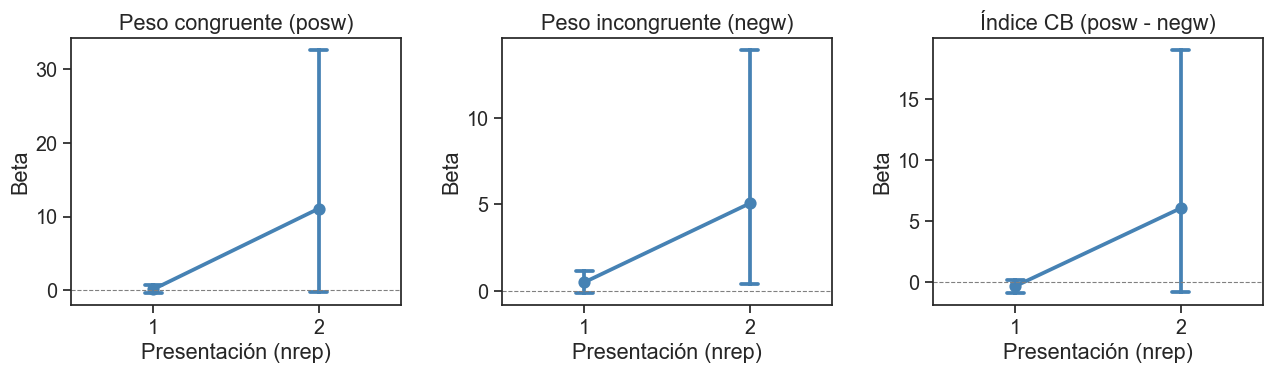

Test t del índice CB contra 0:
nrep=1: t=-1.199, p=0.2424 → no significativo
nrep=2: t=0.981, p=0.3366 → no significativo


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title in zip(axes,
                           ["posw", "negw", "cbias_idx"],
                           ["Peso congruente (posw)",
                            "Peso incongruente (negw)",
                            "Índice CB (posw - negw)"]):
    sns.pointplot(data=df_sim_betas, x="nrep", y=col,
                  capsize=0.1, color="steelblue", ax=ax)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Presentación (nrep)")
    ax.set_ylabel("Beta")

plt.tight_layout()
plt.show()

print("Test t del índice CB contra 0:")
for nrep_val in [1, 2]:
    dat = df_sim_betas[df_sim_betas["nrep"] == nrep_val]["cbias_idx"].dropna()
    t, p = stats.ttest_1samp(dat, 0)
    print(f"nrep={nrep_val}: t={t:.3f}, p={p:.4f} → "          f"{'SIGNIFICATIVO ✓' if p < 0.05 else 'no significativo'}")


Filas originales : 50
Filas tras filtro: 49
Eliminadas       : 1


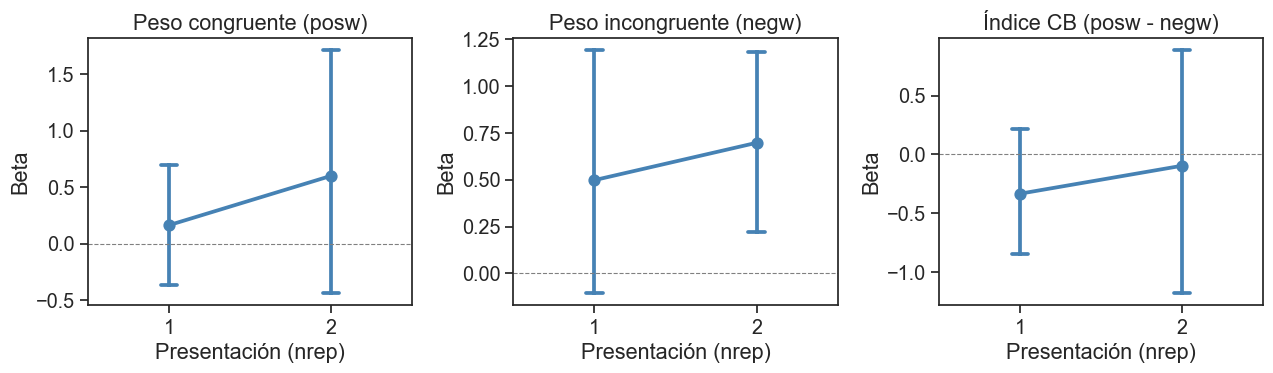

Test t del índice CB contra 0 (tras filtro):
nrep=1: t=-1.199, p=0.2424 → no significativo
nrep=2: t=-0.170, p=0.8666 → no significativo


In [45]:
cbias_limit = 20

df_sim_betas_clean = df_sim_betas[
    np.abs(df_sim_betas["cbias_idx"]) < cbias_limit
].copy()

print(f"Filas originales : {len(df_sim_betas)}")
print(f"Filas tras filtro: {len(df_sim_betas_clean)}")
print(f"Eliminadas       : {len(df_sim_betas) - len(df_sim_betas_clean)}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
                           ["posw", "negw", "cbias_idx"],
                           ["Peso congruente (posw)",
                            "Peso incongruente (negw)",
                            "Índice CB (posw - negw)"]):
    sns.pointplot(data=df_sim_betas_clean, x="nrep", y=col,
                  capsize=0.1, color="steelblue", ax=ax)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Presentación (nrep)")
    ax.set_ylabel("Beta")

plt.tight_layout()
plt.show()

print("Test t del índice CB contra 0 (tras filtro):")
for nrep_val in [1, 2]:
    dat = df_sim_betas_clean[df_sim_betas_clean["nrep"] == nrep_val]["cbias_idx"].dropna()
    t, p = stats.ttest_1samp(dat, 0)
    print(f"nrep={nrep_val}: t={t:.3f}, p={p:.4f} → "          f"{'SIGNIFICATIVO ✓' if p < 0.05 else 'no significativo'}")


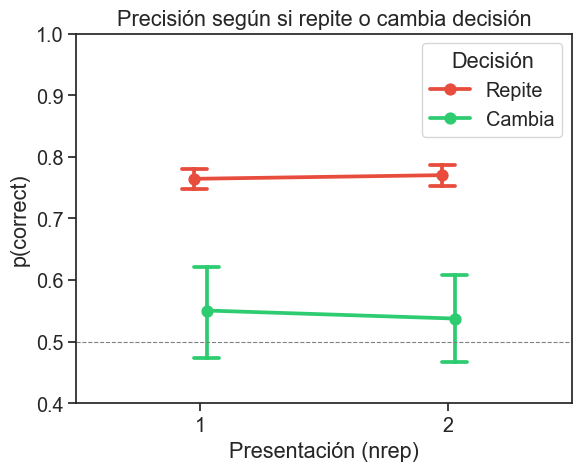

ANOVA — Precisión según switch y trial_type:
                Source        SS  ddof1  ddof2        MS           F  \
0               switch  1.249362      1     24  1.249362  173.945105   
1           trial_type  0.073427      1     24  0.073427    3.907650   
2  switch * trial_type  0.018113      1     24  0.018113    1.243144   

          p_unc     p_GG_corr       ng2  eps  
0  1.726229e-12  1.726229e-12  0.503587  1.0  
1  5.966569e-02  5.966569e-02  0.056267  1.0  
2  2.759066e-01  2.759066e-01  0.014494  1.0  


In [46]:
avg_correct_switch = df_rt.groupby(
    ["subj", "nrep", "switch", "trial_type"], as_index=False
)[["correct"]].mean()

sns.pointplot(
    data=avg_correct_switch[avg_correct_switch["nrep"] > 0],
    x="nrep", y="correct", hue="switch",
    dodge=True, capsize=0.1, palette={0: "#e74c3c", 1: "#2ecc71"}
)
plt.title("Precisión según si repite o cambia decisión")
plt.xlabel("Presentación (nrep)")
plt.ylabel("p(correct)")
plt.ylim(0.4, 1.0)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Repite", "Cambia"], title="Decisión")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
plt.show()

dat = avg_correct_switch[avg_correct_switch["nrep"] > 0].copy()
dat["switch"] = dat["switch"].astype(str)
print("ANOVA — Precisión según switch y trial_type:")
print(pg.rm_anova(dv="correct", within=["switch", "trial_type"],
                  subject="subj", data=dat, detailed=True, correction=True))


  subj trial_type      phit       pfa  stuborness
0  S03  nonrepeat  0.500000  0.142857    0.500000
1  S03     repeat  0.360000  0.129032    0.640000
2  s01  nonrepeat  0.285714  0.014925    0.714286
3  s01     repeat  0.086957  0.031250    0.913043
4  s04  nonrepeat  0.315789  0.014493    0.684211
5  s04     repeat  0.352941  0.028571    0.647059
Media stubbornness: 0.722


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_71586/3142277315.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=switch_str, x="trial_type", y="stuborness",


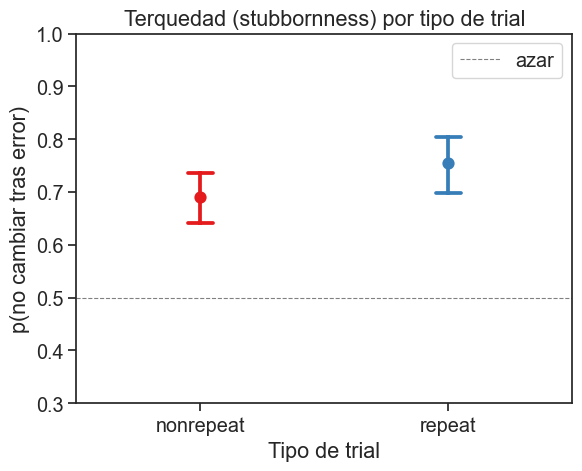

Test t stubbornness contra 0.5:
repeat: t=9.279, p=0.0000 → SIGNIFICATIVO ✓
nonrepeat: t=7.689, p=0.0000 → SIGNIFICATIVO ✓


In [47]:
switch_str = df_rt[df_rt["nrep"] > 0].groupby(
    ["subj", "trial_type"]
).apply(switch_strategy, include_groups=False)
switch_str.reset_index(inplace=True)
switch_str.drop(columns="level_2", errors="ignore", inplace=True)

print(switch_str.head(6))
print(f"Media stubbornness: {switch_str['stuborness'].mean():.3f}")

sns.pointplot(data=switch_str, x="trial_type", y="stuborness",
              capsize=0.1, palette="Set1")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="azar")
plt.title("Terquedad (stubbornness) por tipo de trial")
plt.xlabel("Tipo de trial")
plt.ylabel("p(no cambiar tras error)")
plt.ylim(0.3, 1.0)
plt.legend()
plt.show()

print("Test t stubbornness contra 0.5:")
for tt in ["repeat", "nonrepeat"]:
    dat = switch_str[switch_str["trial_type"] == tt]["stuborness"]
    t, p = stats.ttest_1samp(dat, 0.5)
    print(f"{tt}: t={t:.3f}, p={p:.4f} → "          f"{'SIGNIFICATIVO ✓' if p < 0.05 else 'no significativo'}")


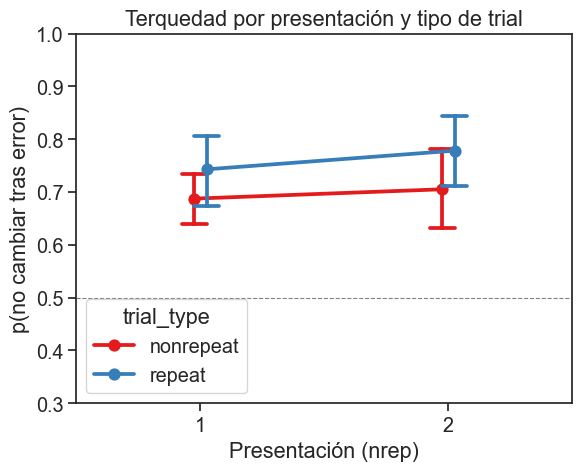

ANOVA — Stubbornness:
              Source        SS  ddof1  ddof2        MS         F     p_unc  \
0               nrep  0.017605      1     24  0.017605  0.585317  0.451694   
1         trial_type  0.103402      1     24  0.103402  8.177425  0.008641   
2  nrep * trial_type  0.001940      1     24  0.001940  0.135136  0.716387   

   p_GG_corr       ng2  eps  
0   0.451694  0.006457  1.0  
1   0.008641  0.036768  1.0  
2   0.716387  0.000715  1.0  


In [48]:
switch_strexp = df_rt[df_rt["nrep"] > 0].groupby(
    ["subj", "nrep", "trial_type"]
).apply(switch_strategy, include_groups=False)
switch_strexp.reset_index(inplace=True)
switch_strexp.drop(columns="level_3", errors="ignore", inplace=True)

sns.pointplot(data=switch_strexp, x="nrep", y="stuborness", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
plt.title("Terquedad por presentación y tipo de trial")
plt.xlabel("Presentación (nrep)")
plt.ylabel("p(no cambiar tras error)")
plt.ylim(0.3, 1.0)
plt.show()

print("ANOVA — Stubbornness:")
print(pg.rm_anova(dv="stuborness", within=["nrep", "trial_type"],
                  subject="subj", data=switch_strexp, detailed=True, correction=True))


In [49]:
# ══════════════════════════════════════════════════════════════
# ANÁLISIS: Probabilidad de estar correcto en función de
# meta-d prime efficiency y si la respuesta anterior fue correcta
# Replicando el análisis del tutor
# ══════════════════════════════════════════════════════════════

df_meta = df_rt[df_rt["nrep"] > 0].copy()
df_meta["prev_correct"] = df_meta["correct-1"].map({1: "Correct", 0: "Incorrect"})

print(f"Trials para el análisis: {len(df_meta)}")
print(f"Distribución correct-1:")
print(df_meta["prev_correct"].value_counts())
print(f"Rango metad: [{df_meta['metad'].min():.3f}, {df_meta['metad'].max():.3f}]")


Trials para el análisis: 4370
Distribución correct-1:
prev_correct
Correct      3162
Incorrect    1208
Name: count, dtype: int64
Rango metad: [0.086, 1.226]


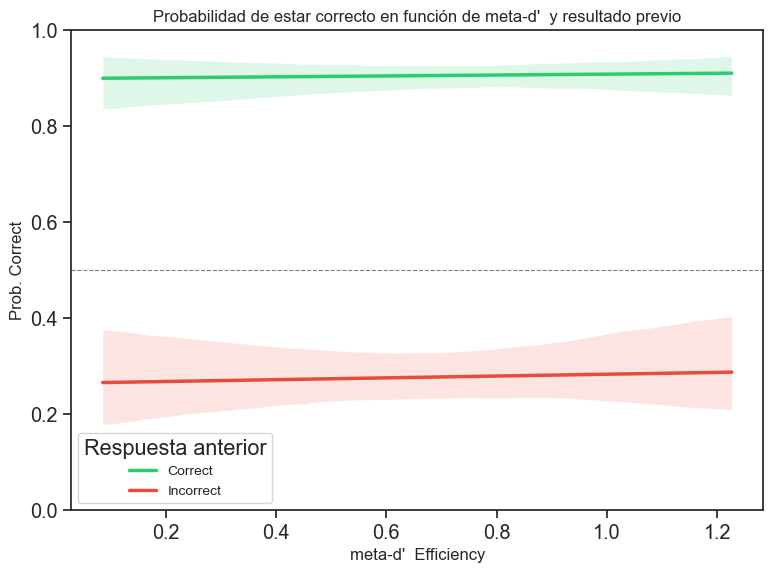

In [50]:
df_by_subj = df_meta.groupby(
    ["subj", "prev_correct", "metad"], as_index=False
)["correct"].mean()
df_by_subj.rename(columns={"correct": "p_correct"}, inplace=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Correct": "#2ecc71", "Incorrect": "#e74c3c"}

for prev, color in colors.items():
    d = df_by_subj[df_by_subj["prev_correct"] == prev]
    sns.regplot(data=d, x="metad", y="p_correct", color=color,
                scatter=False, ci=95, label=prev,
                line_kws={"linewidth": 2.5}, ax=ax)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("meta-d'  Efficiency", fontsize=12)
ax.set_ylabel("Prob. Correct", fontsize=12)
ax.set_title("Probabilidad de estar correcto en función de meta-d'  y resultado previo", fontsize=12)
ax.legend(title="Respuesta anterior", fontsize=10)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()


In [38]:
print("Regresión: p(correct) ~ metad por condición previa (nivel participante)")
print("=" * 60)

for prev in ["Correct", "Incorrect"]:
    d = df_by_subj[df_by_subj["prev_correct"] == prev]
    m = smf.ols("p_correct ~ metad", data=d).fit()
    print(f"Condición previa: {prev}")
    print(f"  Pendiente (beta metad): {m.params['metad']:+.4f}")
    print(f"  p-valor              : {m.pvalues['metad']:.4f} → "          f"{'✓ Significativo' if m.pvalues['metad'] < 0.05 else 'n.s.'}")
    print(f"  R²                   : {m.rsquared:.3f}")
    print()

print("Interpretación esperada (según tutor):")
print("  Correct   → pendiente NEGATIVA")
print("  Incorrect → pendiente POSITIVA y más empinada")


Regresión: p(correct) ~ metad por condición previa (nivel participante)
Condición previa: Correct
  Pendiente (beta metad): +0.0093
  p-valor              : 0.8238 → n.s.
  R²                   : 0.002

Condición previa: Incorrect
  Pendiente (beta metad): +0.0190
  p-valor              : 0.8187 → n.s.
  R²                   : 0.002

Interpretación esperada (según tutor):
  Correct   → pendiente NEGATIVA
  Incorrect → pendiente POSITIVA y más empinada


In [51]:
# ══════════════════════════════════════════════════════════════
# MODELO MIXTO a nivel de trial
# correct ~ metad_z * correct_prev + (1|subj)
# Equivalente a lmer(..., family=binomial) en R
# ══════════════════════════════════════════════════════════════

df_model = df_rt[df_rt["nrep"] > 0].copy()
df_model = df_model.rename(columns={"correct-1": "correct_prev"})
df_model["correct_prev"] = df_model["correct_prev"].astype(float)

# Estandarizamos metad (between-subjects)
df_model["metad_z"] = (
    (df_model["metad"] - df_model["metad"].mean()) /
     df_model["metad"].std()
)

print(f"Trials en el modelo : {len(df_model)}")
print(f"Participantes       : {df_model['subj'].nunique()}")
print(df_model[["subj", "correct", "correct_prev", "metad_z"]].head(6))


Trials en el modelo : 4370
Participantes       : 25
  subj  correct  correct_prev  metad_z
1  s01        1           1.0 -1.75075
2  s01        1           1.0 -1.75075
4  s01        0           0.0 -1.75075
5  s01        0           0.0 -1.75075
7  s01        1           1.0 -1.75075
8  s01        1           1.0 -1.75075


In [ ]:
# ══════════════════════════════════════════════════════════════
# MODELO MIXTO a nivel de trial
# correct ~ metad_z * correct_prev + (1|subj)
# ══════════════════════════════════════════════════════════════

df_model = df_rt[df_rt["nrep"] > 0].copy()
df_model = df_model.rename(columns={"correct-1": "correct_prev"})
df_model["correct_prev"] = df_model["correct_prev"].astype(float)

# Estandarizamos metad (between-subjects)
df_model["metad_z"] = (
    (df_model["metad"] - df_model["metad"].mean()) /
     df_model["metad"].std()
)

df_model = df_model.dropna(subset=["correct", "correct_prev", "metad_z"]).reset_index(drop=True)

print(f"Trials en el modelo : {len(df_model)}")
print(f"Participantes       : {df_model['subj'].nunique()}")
print(df_model[["subj", "correct", "correct_prev", "metad_z"]].head(6))

Trials en el modelo : 4195
Participantes       : 24
  subj  correct  correct_prev  metad_z
0  s01        1           1.0 -1.75075
1  s01        1           1.0 -1.75075
2  s01        0           0.0 -1.75075
3  s01        0           0.0 -1.75075
4  s01        1           1.0 -1.75075
5  s01        1           1.0 -1.75075


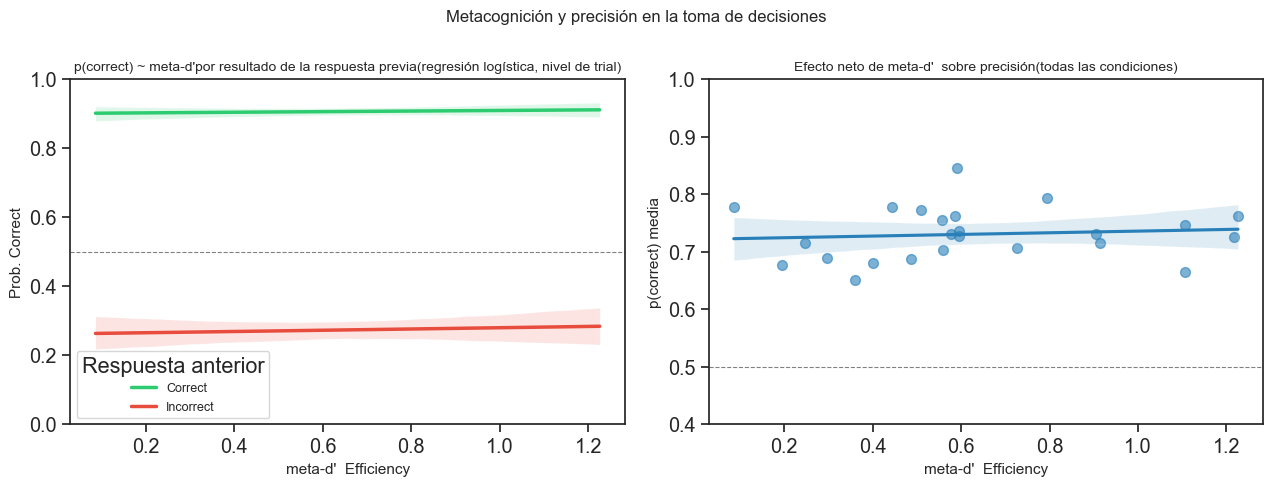

Regresión logística por condición previa (nivel de trial):
Condición previa: Correct (n=3033 trials)
  Pendiente (beta metad): +0.1014
  p-valor              : 0.6169 → n.s.

Condición previa: Incorrect (n=1162 trials)
  Pendiente (beta metad): +0.0915
  p-valor              : 0.6620 → n.s.

Correlación global metad ~ p(correct):
          n    r           CI95  p_val  BF10  power
pearson  24  0.1  [-0.32, 0.48]  0.642  0.28  0.075


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_map = {1.0: "#2ecc71", 0.0: "#e74c3c"}
labels_map = {1.0: "Correct", 0.0: "Incorrect"}

# Panel izquierdo: regresión logística a nivel de trial
for prev_val, color in colors_map.items():
    d = df_model[df_model["correct_prev"] == prev_val]
    sns.regplot(data=d, x="metad", y="correct", color=color,
                scatter=False, ci=95, logistic=True,
                label=labels_map[prev_val],
                line_kws={"linewidth": 2.5}, ax=axes[0])

axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("meta-d'  Efficiency", fontsize=11)
axes[0].set_ylabel("Prob. Correct", fontsize=11)
axes[0].set_title("p(correct) ~ meta-d'por resultado de la respuesta previa"                  "(regresión logística, nivel de trial)", fontsize=10)
axes[0].legend(title="Respuesta anterior", fontsize=9)
axes[0].set_ylim(0, 1.0)

# Panel derecho: efecto neto global
df_overall = df_meta.groupby(["subj", "metad"], as_index=False)["correct"].mean()
sns.regplot(data=df_overall, x="metad", y="correct",
            color="#2980b9", scatter=True, ci=95,
            scatter_kws={"alpha": 0.6, "s": 50}, ax=axes[1])
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("meta-d'  Efficiency", fontsize=11)
axes[1].set_ylabel("p(correct) media", fontsize=11)
axes[1].set_title("Efecto neto de meta-d'  sobre precisión(todas las condiciones)", fontsize=10)
axes[1].set_ylim(0.4, 1.0)

plt.suptitle("Metacognición y precisión en la toma de decisiones", fontsize=12)
plt.tight_layout()
plt.show()

print("Regresión logística por condición previa (nivel de trial):")
print("=" * 60)
for prev_val, label in [(1.0, "Correct"), (0.0, "Incorrect")]:
    d = df_model[df_model["correct_prev"] == prev_val]
    m = smf.glm("correct ~ metad", data=d, family=sm.families.Binomial()).fit()
    coef = m.params["metad"]
    pval = m.pvalues["metad"]
    print(f"Condición previa: {label} (n={len(d)} trials)")
    print(f"  Pendiente (beta metad): {coef:+.4f}")
    print(f"  p-valor              : {pval:.4f} → "          f"{'✓ Significativo' if pval < 0.05 else 'n.s.'}")
    print()

corr = pg.corr(df_overall["metad"], df_overall["correct"], method="pearson")
print("Correlación global metad ~ p(correct):")
print(corr.round(3))


In [55]:
# Índice de CB por participante
cbias_summary = df_sim_betas_clean.groupby(
    ["subj"], as_index=False
)[["posw", "negw", "cbias_idx"]].mean()

# Metad por participante
metad_summary = df_rt.groupby("subj", as_index=False)["metad"].first()

# Weight y PSE medios
logreg_summary = log_reg_nrep.groupby(
    ["subj"], as_index=False
)[["weight", "PSE", "intercept"]].mean()

# p(repetir) por participante
prepeat_summary = avg_switch.groupby("subj", as_index=False)[["p_repeat"]].mean()

# Stubbornness media
stub_avg = switch_str.groupby("subj", as_index=False)["stuborness"].mean()

# Precisión media
avg_correct_subj = df_rt.groupby(["subj", "nrep", "trial_type"], as_index=False)[["correct"]].mean()
correct_avg = avg_correct_subj.groupby("subj", as_index=False)["correct"].mean()

# Unimos todo
summary_df = cbias_summary.copy()
summary_df = summary_df.merge(metad_summary,   on="subj", how="left")
summary_df = summary_df.merge(logreg_summary,  on="subj", how="left")
summary_df = summary_df.merge(prepeat_summary, on="subj", how="left")
summary_df = summary_df.merge(stub_avg,        on="subj", how="left")
summary_df = summary_df.merge(correct_avg,     on="subj", how="left")

print(f"Dataframe resumen: {summary_df.shape}")
print(summary_df.round(3))


Dataframe resumen: (25, 11)
   subj   posw   negw  cbias_idx  metad  weight    PSE  intercept  p_repeat  \
0   S03  1.232  1.555     -0.324  0.556   7.244 -0.153      1.065     0.720   
1   s01  3.387  1.469      1.918  0.086   8.921 -0.088      0.729     0.822   
2   s04  1.247  2.189     -0.942  0.591   6.706 -0.060      0.370     0.794   
3   s05 -0.648  1.125     -1.774  0.558   7.685 -0.200      1.472     0.796   
4   s07 -2.312 -0.156     -2.156  0.596   7.071 -0.002      0.026     0.742   
5   s08  1.252  0.190      1.061  0.727   6.798  0.117     -0.746     0.730   
6   s09  1.022  0.395      0.627  1.107   4.554 -0.066      0.335     0.782   
7   s10  1.746  1.187      0.559  1.217   5.973  0.040     -0.260     0.789   
8   s11  0.675 -0.486      1.161  0.509   7.568 -0.060      0.552     0.766   
9   s12 -2.176 -0.575     -1.601  0.487   4.845 -0.242      1.224     0.794   
10  s13 -3.597  0.949     -4.546  0.794   6.324 -0.088      0.541     0.788   
11  s14  0.418  0.439   

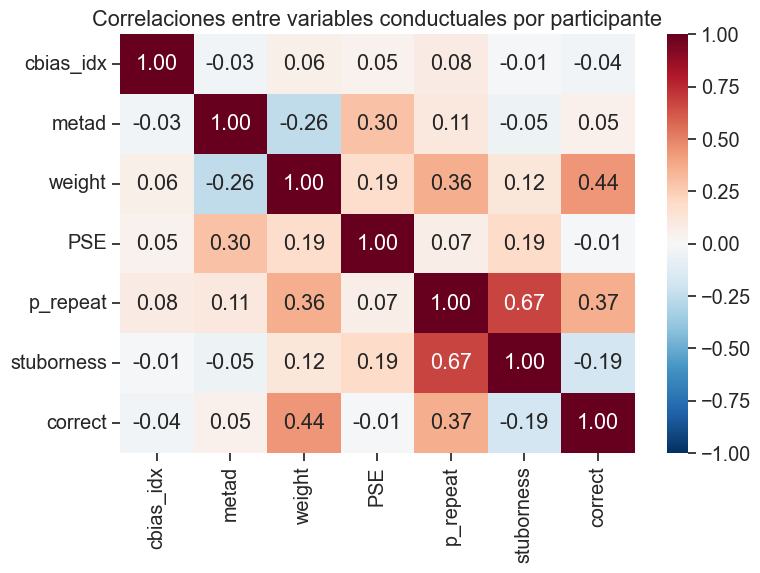

In [56]:
vars_corr = ["cbias_idx", "metad", "weight", "PSE",
             "p_repeat", "stuborness", "correct"]

corr_matrix = summary_df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
plt.title("Correlaciones entre variables conductuales por participante")
plt.tight_layout()
plt.show()


In [57]:
summary_df.to_csv("summary_behavioural.csv", index=False)
print("Guardado: summary_behavioural.csv")

df_rt.to_csv("CJ_EEG_clean.csv", index=False)
print("Guardado: CJ_EEG_clean.csv")

print(f"  Resumen final:")
print(f"  Participantes          : {summary_df.shape[0]}")
print(f"  Variables en resumen   : {summary_df.shape[1]}")
print(f"  Trials en dataset limpio: {df_rt.shape[0]}")
print(f"  Variables en dataset   : {df_rt.shape[1]}")


Guardado: summary_behavioural.csv
Guardado: CJ_EEG_clean.csv
  Resumen final:
  Participantes          : 25
  Variables en resumen   : 11
  Trials en dataset limpio: 6537
  Variables en dataset   : 40
